In [1]:
# 1. Import our data manipulation library
import pandas as pd

# 2. Load the dataset
# Why '../'? Our notebook is inside the 'notebooks' folder. 
# '../' tells Python to go UP one folder to the main project folder, then dive into 'data/raw'
file_path = '../data/raw/credit_risk_dataset.csv'
df = pd.read_csv(file_path)

# 3. Check the size of the data
print(f"Dataset Shape: {df.shape[0]} rows, {df.shape[1]} columns\n")

# 4. View the first 5 rows
print("--- FIRST 5 ROWS ---")
display(df.head())

# 5. Check data types and look for missing values
print("\n--- DATA TYPES & INFO ---")
df.info()

# 6. Generate summary statistics for numerical columns
print("\n--- SUMMARY STATISTICS ---")
display(df.describe())

# 7. Count exact missing values per column
print("\n--- MISSING VALUE COUNT ---")
print(df.isnull().sum())

Dataset Shape: 32581 rows, 12 columns

--- FIRST 5 ROWS ---


,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4



--- DATA TYPES & INFO ---
<class 'pandas.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  str    
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  str    
 5   loan_grade                  32581 non-null  str    
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  str    
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), str(4)
memory usage: 3.0 MB

--- SUMMARY STATIS

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
count,32581.000000,3.258100e+04,31686.000000,32581.000000,29465.000000,32581.000000,32581.000000,32581.000000
mean,27.734600,6.607485e+04,4.789686,9589.371106,11.011695,0.218164,0.170203,5.804211
std,6.348078,6.198312e+04,4.142630,6322.086646,3.240459,0.413006,0.106782,4.055001
min,20.000000,4.000000e+03,0.000000,500.000000,5.420000,0.000000,0.000000,2.000000
25%,23.000000,3.850000e+04,2.000000,5000.000000,7.900000,0.000000,0.090000,3.000000
50%,26.000000,5.500000e+04,4.000000,8000.000000,10.990000,0.000000,0.150000,4.000000
75%,30.000000,7.920000e+04,7.000000,12200.000000,13.470000,0.000000,0.230000,8.000000
max,144.000000,6.000000e+06,123.000000,35000.000000,23.220000,1.000000,0.830000,30.000000



--- MISSING VALUE COUNT ---
person_age                       0
person_income                    0
person_home_ownership            0
person_emp_length              895
loan_intent                      0
loan_grade                       0
loan_amnt                        0
loan_int_rate                 3116
loan_status                      0
loan_percent_income              0
cb_person_default_on_file        0
cb_person_cred_hist_length       0
dtype: int64


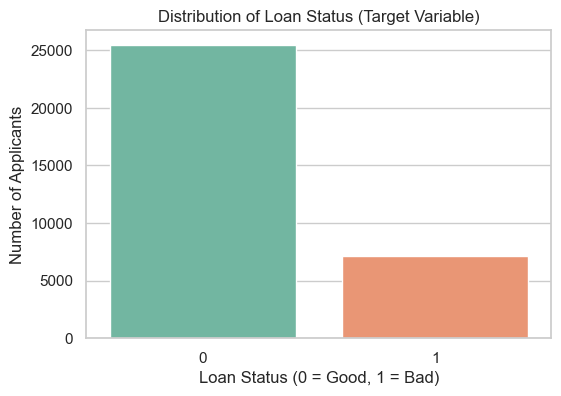

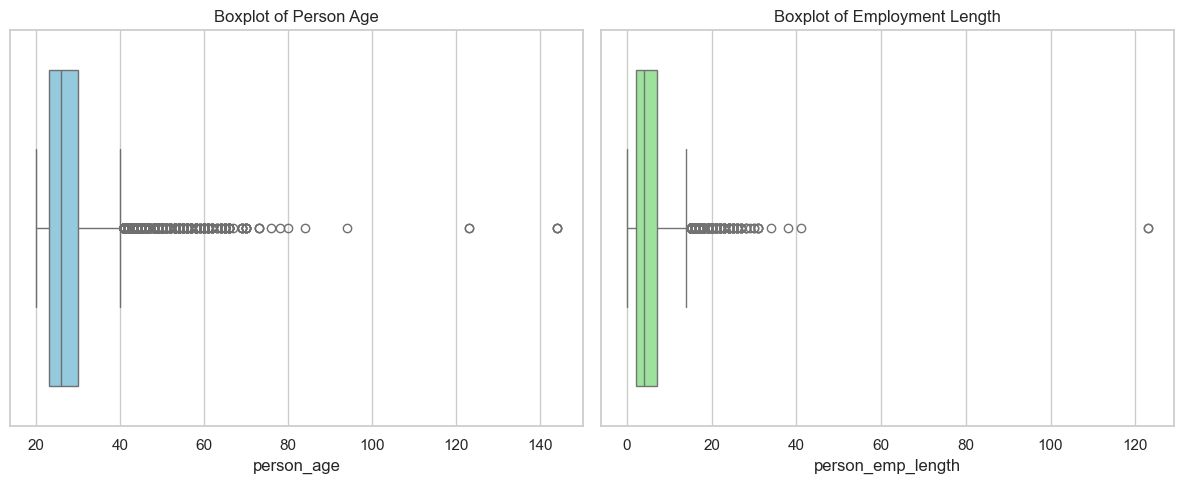

In [2]:
# 1. Import our visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Set a nice visual style for our plots
sns.set_theme(style="whitegrid")

# 2. Visualize the Target Variable (Loan Status)
# In this dataset: 0 = Non-Default (Good Risk), 1 = Default (Bad Risk)
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='loan_status', hue='loan_status', palette='Set2', legend=False)
plt.title('Distribution of Loan Status (Target Variable)')
plt.ylabel('Number of Applicants')
plt.xlabel('Loan Status (0 = Good, 1 = Bad)')
plt.show()

# 3. Visualize Outliers using Boxplots
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Boxplot for Age
sns.boxplot(data=df, x='person_age', ax=axes[0], color='skyblue')
axes[0].set_title('Boxplot of Person Age')

# Boxplot for Employment Length
sns.boxplot(data=df, x='person_emp_length', ax=axes[1], color='lightgreen')
axes[1].set_title('Boxplot of Employment Length')

plt.tight_layout()
plt.show()

In [3]:
# 1. OUTLIER REMOVAL
# Keep only rows where age is <= 100 and employment length is <= 60
print(f"Rows before removing outliers: {df.shape[0]}")
df = df[(df['person_age'] <= 100)]
# We also have to handle the fact that person_emp_length has missing values.
# We don't want to accidentally drop the missing values yet, so we keep rows <= 60 OR rows that are null.
df = df[(df['person_emp_length'] <= 60) | (df['person_emp_length'].isnull())]
print(f"Rows after removing outliers: {df.shape[0]}\n")

# 2. MISSING VALUE HANDLING (IMPUTATION)
print("--- MISSING VALUES BEFORE ---")
print(df[['person_emp_length', 'loan_int_rate']].isnull().sum())

# Calculate the median for the missing columns
emp_median = df['person_emp_length'].median()
int_rate_median = df['loan_int_rate'].median()

# Fill the blank spaces with the median values
df['person_emp_length'] = df['person_emp_length'].fillna(emp_median)
df['loan_int_rate'] = df['loan_int_rate'].fillna(int_rate_median)

print("\n--- MISSING VALUES AFTER ---")
print(df[['person_emp_length', 'loan_int_rate']].isnull().sum())

Rows before removing outliers: 32581
Rows after removing outliers: 32574

--- MISSING VALUES BEFORE ---
person_emp_length     895
loan_int_rate        3115
dtype: int64

--- MISSING VALUES AFTER ---
person_emp_length    0
loan_int_rate        0
dtype: int64


In [4]:
# 1. Identify which columns contain text (categorical data)
categorical_columns = df.select_dtypes(include=['object']).columns
print(f"Text columns found: {list(categorical_columns)}\n")

# 2. Apply One-Hot Encoding using pandas 'get_dummies'
# 'drop_first=True' drops one category per column to prevent the Dummy Variable Trap
df_encoded = pd.get_dummies(df, columns=categorical_columns, drop_first=True)

# Convert boolean columns (True/False) that get_dummies sometimes creates into 1s and 0s
df_encoded = df_encoded.astype(int)

# 3. Check the results
print(f"Shape BEFORE encoding: {df.shape}")
print(f"Shape AFTER encoding:  {df_encoded.shape}\n")

print("--- FIRST 5 ROWS AFTER ENCODING ---")
display(df_encoded.head())

Text columns found: ['person_home_ownership', 'loan_intent', 'loan_grade', 'cb_person_default_on_file']

Shape BEFORE encoding: (32574, 12)
Shape AFTER encoding:  (32574, 23)

--- FIRST 5 ROWS AFTER ENCODING ---


C:\Users\SUCHISMITA\AppData\Local\Temp\ipykernel_19200\4244606600.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = df.select_dtypes(include=['object']).columns


,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length,person_home_ownership_OTHER,person_home_ownership_OWN,...,loan_intent_MEDICAL,loan_intent_PERSONAL,loan_intent_VENTURE,loan_grade_B,loan_grade_C,loan_grade_D,loan_grade_E,loan_grade_F,loan_grade_G,cb_person_default_on_file_Y
1,21,9600,5,1000,11,0,0,2,0,1,...,0,0,0,1,0,0,0,0,0,0
2,25,9600,1,5500,12,1,0,3,0,0,...,1,0,0,0,1,0,0,0,0,0
3,23,65500,4,35000,15,1,0,2,0,0,...,1,0,0,0,1,0,0,0,0,0
4,24,54400,8,35000,14,1,0,4,0,0,...,1,0,0,0,1,0,0,0,0,1
5,21,9900,2,2500,7,1,0,2,0,1,...,0,0,1,0,0,0,0,0,0,0


In [5]:
# 1. FEATURE ENGINEERING: Calculate Loan-to-Income Ratio
# This tells us what percentage of their income is being consumed by this loan
df_encoded['loan_to_income_ratio'] = df_encoded['loan_amnt'] / df_encoded['person_income']

print("--- NEW FEATURE ADDED ---")
# Let's peek at the specific columns we just used
display(df_encoded[['loan_amnt', 'person_income', 'loan_to_income_ratio']].head())


# 2. SAVE THE PROCESSED DATASET
# We use index=False so Pandas doesn't save the row numbers as an extra useless column
processed_file_path = '../data/processed/credit_risk_processed.csv'
df_encoded.to_csv(processed_file_path, index=False)

print(f"\n✅ SUCCESS! Clean data saved to: {processed_file_path}")

--- NEW FEATURE ADDED ---


,loan_amnt,person_income,loan_to_income_ratio
1,1000,9600,0.104167
2,5500,9600,0.572917
3,35000,65500,0.534351
4,35000,54400,0.643382
5,2500,9900,0.252525



✅ SUCCESS! Clean data saved to: ../data/processed/credit_risk_processed.csv
